# Draft-Board Feature Validation
*Justin McKendry*

---

## Purpose (reframed)

This notebook used to *compute* the live draft score directly — it fit a linear regression once, hardcoded the resulting weights, and exported them to a static `players.json` consumed by the React draft board. That made it a second, disconnected scoring system living alongside `src/scoring.py` (the one the FastAPI backend actually uses live during a draft), and the two disagreed.

**This notebook's job now is narrower and more honest: feature validation.** It asks *"which preseason-available signals actually predict a player's in-season value over replacement?"* using proper train/test evaluation across multiple seasons, and reports real accuracy metrics instead of a single unvalidated fit. Its findings (e.g. whether last year's per-game average is worth weighting) inform the constants in `src/scoring.py` — that module remains the single place the live draft score is computed, for both the API and the static fallback export at the bottom of this notebook.

**What changed from the original version, and why:**
- **Multicollinearity fix:** the original fit `projected_points`, `proj_vorp`, and `avg_last_year` together, but `proj_vorp` is arithmetically derived from `projected_points` (`proj_vorp = projected_points - replacement_baseline`), so the two are highly collinear. That's why the original fit produced a *negative* coefficient on `projected_points` (-0.13) even though higher-projected players are obviously not worth less — a textbook multicollinearity symptom, not a real effect. We check this with a VIF-style diagnostic below and drop the redundant feature.
- **Real train/test validation:** the original fit on one season and read the coefficients off the same data with no holdout — so "accuracy" was never actually measured. We use a walk-forward split (train on earlier seasons, hold out the most recent as a test set) plus cross-validation across seasons.
- **Model comparison:** Linear Regression, Ridge, and Random Forest are compared via cross-validated RMSE/MAE/R², and the winner is picked on that evidence rather than assumed.
- **Uncertainty:** the original gave a single point estimate with no sense of how reliable it was. We add bootstrap confidence intervals so predictions come with an honest error range.
- **Consistent VORP definition:** replacement baselines are computed via `src/scoring.py` (teams x roster slots), the same definition used everywhere else in the project, instead of a third set of hardcoded position-rank windows.


In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `src.*` and `notebooks.config` are importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from config import CURRENT_SEASON, NEXT_SEASON, TEAMS, ROSTER_NEEDS, POSITIONS
from src.scoring import compute_baselines, add_vorp, add_vorp_z, normalize_position

# --- Configuration for Jupyter ---
%config InlineBackend.figure_formats = ['svg']


In [2]:
engine = create_engine("sqlite:///../data/fantasy_data.db")

## 1. Build a multi-season training set

For every season we have both a preseason projection and a real outcome for, we build one row per
player with:

- `projected_points` — ESPN's preseason projection for that season
- `proj_vorp` — that projection expressed as value over replacement, using the *same* baseline definition (`src/scoring.compute_baselines`) as the live recommender: the worst starter's points given this league's `teams x roster slots`
- `avg_last_year` — the player's per-game average from the *previous* season (0 if none, e.g. rookies)
- **`opportunities_last_year`** — last season's total touches-or-looks: receiving targets + rushing attempts + passing attempts
- **`opportunities_per_game`** — the same figure divided by last season's games played
- **`is_rookie`** — 1 when the player has no prior season on record at all
- `actual_vorp` — the target: the player's real season points expressed as value over replacement, using the same baseline logic applied to actual points

**Why usage, and why *last* season's?** Fantasy points are downstream of opportunity: a running
back who gets 300 carries will out-score an equally talented one who gets 100. The strict
constraint is that every feature must be knowable **on draft day**. Last season's usage is;
*this* season's is the outcome we're trying to predict. So all usage columns come from the
`prev` join (year − 1) and never from `ps.actual_*`.

We also deliberately avoid ESPN's `proj_receivingTargets` and its siblings, even though they'd be
draft-day-legal: they carry the same 2023 extraction gap as `projected_points` (58 rows in 2023
vs. ~304 in every other season), which would quietly bias the training set.

**`is_rookie` instead of a silent zero.** Previously rookies got `avg_last_year = 0` via `fillna`,
which tells the model "played last season, produced nothing" — the same signal as a healthy
scratch. The explicit indicator lets the model learn that a zero here means *unknown*.

**2023 is excluded.** That season's `projected_points` was recorded as `0.0` for 392 of 480
players (an extraction gap, verified against the raw source — e.g. Patrick Mahomes shows
`points=267.0` but `projected_points=0.0`). Keeping it would mean training on `proj_vorp` values
computed from a projection of zero. The 88 players whose projections *did* record are not a random
sample of the league, so we drop the season entirely rather than train on the survivors. 2023 rows
are still read as the `prev` year that supplies 2024's usage and recency features — that data is
fine; it's only the *projections* that are missing.

Positions come from `players_stats.position`, which as of NB02 is derived from `eligible_slots`
rather than the player's lineup slot. Before that fix this notebook trained on ~96–112 players per
season; it now sees ~420–460.

In [3]:
# Seasons whose *projections* are trustworthy enough to train on. 2023 is
# absent because 392 of its 480 rows have projected_points == 0 (an extraction
# gap, not real zeros); it is still read via the `prev` join below to supply
# 2024's last-season features.
BROKEN_PROJECTION_YEARS = [2023]
FEATURE_YEARS = [y for y in range(2021, CURRENT_SEASON + 1) if y not in BROKEN_PROJECTION_YEARS]
# 2020 never appears as a target year - it exists only to seed 2021's prev-season features.


def build_feature_frame(engine, year):
    """One row per player for `year`, with only draft-day-knowable features.

    Every `prev.*` column is last season's realised value (knowable in July);
    every `ps.actual_*` column would be this season's outcome and is therefore
    off limits as a feature - `ps.points` appears solely as the target.
    """
    query = """
    SELECT ps.player_id, ps.player_name, ps.position,
           ps.projected_points, ps.points AS actual_points,
           prev.avg_points               AS avg_last_year,
           prev.actual_receivingTargets  AS targets_last_year,
           prev.actual_rushingAttempts   AS rush_att_last_year,
           prev.actual_passingAttempts   AS pass_att_last_year,
           prev.games_played             AS games_last_year,
           prev.player_id                AS prev_player_id
    FROM players_stats ps
    LEFT JOIN players_stats prev
        ON prev.player_id = ps.player_id AND prev.year = ps.year - 1
    WHERE ps.year = :year
    """
    df = pd.read_sql(text(query), engine, params={"year": year})
    df["position"] = df["position"].map(normalize_position)
    df = df[df["position"].isin(POSITIONS)]
    df = df.dropna(subset=["projected_points", "actual_points"])
    # projected_points == 0 is a missing-data sentinel, not a real projection
    # (see the 2023 note above); a handful of such rows exist in other years too.
    df = df[df["projected_points"] != 0]

    # No prior-season row at all means "rookie / unknown", which is a different
    # thing from "played and produced nothing". Flag it before filling zeros so
    # the model can tell the two apart.
    df["is_rookie"] = df["prev_player_id"].isna().astype(int)

    usage_cols = ["avg_last_year", "targets_last_year", "rush_att_last_year",
                  "pass_att_last_year", "games_last_year"]
    df[usage_cols] = df[usage_cols].fillna(0)

    # One combined volume term rather than three position-specific ones: targets
    # are structurally zero for QBs, pass attempts for WRs, and so on, so fitting
    # them separately mostly fits which position a player is, not how used he was.
    df["opportunities_last_year"] = (
        df["targets_last_year"] + df["rush_att_last_year"] + df["pass_att_last_year"]
    )
    # Per-game separates "genuinely heavily used" from "merely healthy for 17 weeks".
    df["opportunities_per_game"] = np.where(
        df["games_last_year"] > 0,
        df["opportunities_last_year"] / df["games_last_year"],
        0.0,
    )

    proj_baselines = compute_baselines(df, teams=TEAMS, roster_needs=ROSTER_NEEDS, value_col="projected_points")
    df = add_vorp(df, proj_baselines, value_col="projected_points", out_col="proj_vorp").drop(columns="baseline")

    actual_baselines = compute_baselines(df, teams=TEAMS, roster_needs=ROSTER_NEEDS, value_col="actual_points")
    df = add_vorp(df, actual_baselines, value_col="actual_points", out_col="actual_vorp").drop(columns="baseline")

    df["year"] = year
    return df.drop(columns="prev_player_id")


training_df = pd.concat([build_feature_frame(engine, y) for y in FEATURE_YEARS], ignore_index=True)
print(f"Training rows: {len(training_df)} across seasons {FEATURE_YEARS} "
      f"(2023 excluded: broken projections)")
print(f"Rookies (no prior season): {training_df['is_rookie'].sum()} "
      f"({training_df['is_rookie'].mean():.1%})")
training_df.groupby("year").size()

Training rows: 1751 across seasons [2021, 2022, 2024, 2025] (2023 excluded: broken projections)
Rookies (no prior season): 363 (20.7%)


year
2021    419
2022    424
2024    462
2025    446
dtype: int64

## 2. Multicollinearity check

If `projected_points` and `proj_vorp` are (almost) redundant, including both as regressors makes coefficients unstable and can flip signs, as happened in the original notebook. We check with a simple VIF-style diagnostic: regress each candidate feature on the others and look at `1 / (1 - R^2)`. Values above ~5-10 are generally considered problematic.

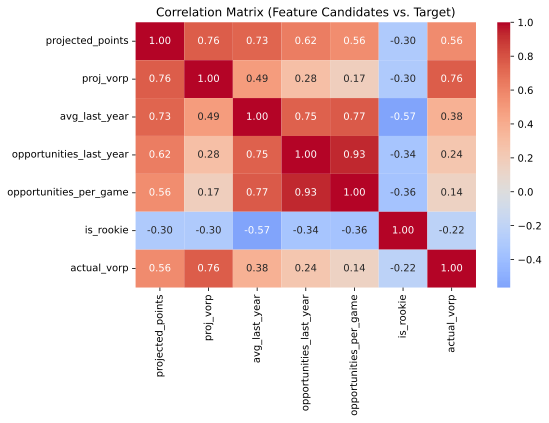

VIF(opportunities_per_game) = 9.8  <-- collinear
VIF(opportunities_last_year) = 8.2  <-- collinear
VIF(avg_last_year) = 5.0
VIF(projected_points) = 4.8
VIF(proj_vorp) = 3.2
VIF(is_rookie) = 1.6


In [4]:
candidate_features = [
    "projected_points", "proj_vorp", "avg_last_year",
    "opportunities_last_year", "opportunities_per_game", "is_rookie",
]

corr = training_df[candidate_features + ["actual_vorp"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Feature Candidates vs. Target)")
plt.tight_layout()
plt.show()


def variance_inflation_factors(df, features):
    vifs = {}
    for f in features:
        others = [x for x in features if x != f]
        r2 = LinearRegression().fit(df[others], df[f]).score(df[others], df[f])
        vifs[f] = float("inf") if r2 >= 1 else 1 / (1 - r2)
    return vifs


vifs = variance_inflation_factors(training_df, candidate_features)
for f, v in sorted(vifs.items(), key=lambda kv: -kv[1]):
    flag = "  <-- collinear" if v > 5 else ""
    print(f"VIF({f}) = {v:.1f}{flag}")

**Decision: drop `projected_points` as a standalone regressor, keep the rest.**

`projected_points` (VIF ≈ 4.8) and `proj_vorp` (≈ 3.2) are largely the same signal — `proj_vorp`
*is* `projected_points` minus a per-position constant. Since `proj_vorp` already encodes both the
projection level and position scarcity, we keep it and drop the standalone points term. This is
also what fixes the original notebook's sign-flipped, uninterpretable coefficient on
`projected_points`.

The two usage terms are the most collinear things here — `opportunities_per_game` at VIF ≈ 9.8 and
`opportunities_last_year` at ≈ 8.2, which is unsurprising given one is the other divided by games,
and both correlate with `avg_last_year` (≈ 5.0). Values that high mean **individual coefficients on
these terms should not be read as effect sizes.** We keep both anyway, because the question this
notebook asks is "does this signal add predictive value", not "what is its isolated coefficient" —
and the ablation in §5b answers that directly, on held-out data, where collinearity doesn't distort
the verdict. `is_rookie` is essentially independent (VIF ≈ 1.6).

Candidate feature set: **`proj_vorp`, `avg_last_year`, `opportunities_last_year`,
`opportunities_per_game`, `is_rookie`** → target **`actual_vorp`**.

## 3. Walk-forward train/test split

We hold out the most recently completed season (**CURRENT_SEASON**) entirely as a test set, and train on every earlier season. This mirrors how the model would actually be used — predicting an unseen future season from past ones — instead of the original approach of fitting and reading coefficients off the same data.

In [5]:
FEATURES = ["proj_vorp", "avg_last_year",
            "opportunities_last_year", "opportunities_per_game", "is_rookie"]
TARGET = "actual_vorp"

test_year = CURRENT_SEASON
train_years = [y for y in FEATURE_YEARS if y != test_year]

train_df = training_df[training_df["year"].isin(train_years)].reset_index(drop=True)
test_df = training_df[training_df["year"] == test_year].reset_index(drop=True)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Train seasons: {train_years} ({len(train_df)} rows)  |  Test season: {test_year} ({len(test_df)} rows)")

Train seasons: [2021, 2022, 2024] (1305 rows)  |  Test season: 2025 (446 rows)


## 4. Model comparison

We compare Linear Regression, Ridge (regularized linear), and Random Forest using `GroupKFold` cross-validation *within the training seasons only* (grouped by year, so a fold never trains and validates on the same season). This is more honest than a random K-fold, since randomly shuffled rows would let information from a given season leak across folds.

In [6]:
candidates = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=5, random_state=42),
}

n_groups = train_df["year"].nunique()
gkf = GroupKFold(n_splits=min(n_groups, 4))
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}

comparison_rows = []
for name, model in candidates.items():
    cv = cross_validate(model, X_train, y_train, groups=train_df["year"], cv=gkf, scoring=scoring)
    comparison_rows.append({
        "model": name,
        "cv_rmse": -cv["test_rmse"].mean(),
        "cv_mae": -cv["test_mae"].mean(),
        "cv_r2": cv["test_r2"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("cv_rmse")
comparison_df

,model,cv_rmse,cv_mae,cv_r2
1,Ridge,48.691112,36.105095,0.567563
0,Linear,48.691118,36.105024,0.567563
2,RandomForest,50.122035,37.980947,0.542325


In [7]:
best_model_name = comparison_df.iloc[0]["model"]
best_model = clone(candidates[best_model_name]).fit(X_train, y_train)
print(f"Selected model: {best_model_name} (lowest cross-validated RMSE across training seasons)")

Selected model: Ridge (lowest cross-validated RMSE across training seasons)


## 5. Holdout evaluation

Now we evaluate the selected model on the **CURRENT_SEASON** season it never saw during training or cross-validation — this is the real test of predictive accuracy.

Holdout (2025) RMSE: 56.89
Holdout (2025) MAE:  42.62
Holdout (2025) R^2:  0.552


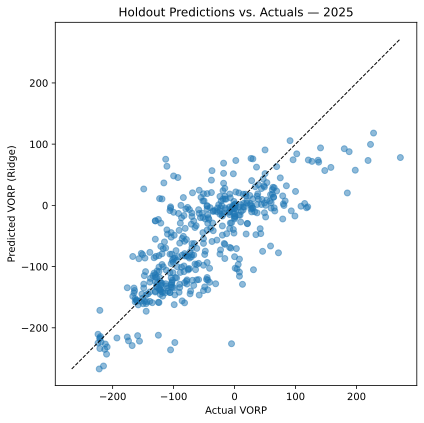

In [8]:
test_pred = best_model.predict(X_test)

holdout_rmse = mean_squared_error(y_test, test_pred) ** 0.5
holdout_mae = mean_absolute_error(y_test, test_pred)
holdout_r2 = r2_score(y_test, test_pred)

print(f"Holdout ({test_year}) RMSE: {holdout_rmse:.2f}")
print(f"Holdout ({test_year}) MAE:  {holdout_mae:.2f}")
print(f"Holdout ({test_year}) R^2:  {holdout_r2:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.5)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Actual VORP")
plt.ylabel(f"Predicted VORP ({best_model_name})")
plt.title(f"Holdout Predictions vs. Actuals — {test_year}")
plt.tight_layout()
plt.savefig("../docs/charts/nb04_holdout_fit.png")
plt.show()

**Honest limitation:** this is still a small dataset (a handful of NFL seasons, one league's worth of drafted players), so treat these metrics as directional rather than precise. The point of walk-forward validation isn't to claim a highly accurate model — it's to replace an unvalidated fit with one whose accuracy is actually measured, so we know roughly how much to trust it.

## 5b. Ablation: does each feature actually earn its place?

A single headline R² can't tell you *which* feature is doing the work. Here we refit the selected
model on the same walk-forward split, adding one group of features at a time, and read the holdout
metrics off each:

1. `proj_vorp` alone — ESPN's projection, converted to value over replacement
2. `+ avg_last_year` — last season's per-game scoring (the recency signal)
3. `+ usage` — `opportunities_last_year`, `opportunities_per_game`
4. `+ is_rookie` — the explicit no-prior-season flag

This is the honest way to answer "would a better feature set help, or is this the ceiling?" If a
group adds nothing here, on data the model never saw, then it adds nothing — regardless of how
plausible it looked going in.

In [9]:
ablation_steps = [
    ("1. proj_vorp only", ["proj_vorp"]),
    ("2. + avg_last_year", ["proj_vorp", "avg_last_year"]),
    ("3. + usage", ["proj_vorp", "avg_last_year",
                    "opportunities_last_year", "opportunities_per_game"]),
    ("4. + is_rookie", FEATURES),
]

ablation_rows = []
for label, feats in ablation_steps:
    # Same model class and same walk-forward split every time - the feature set
    # is the only thing that varies, so any movement in the metrics is
    # attributable to the features rather than to the model or the split.
    model = clone(candidates[best_model_name]).fit(train_df[feats], y_train)
    pred = model.predict(test_df[feats])
    ablation_rows.append({
        "feature set": label,
        "n features": len(feats),
        "holdout rmse": mean_squared_error(y_test, pred) ** 0.5,
        "holdout mae": mean_absolute_error(y_test, pred),
        "holdout r2": r2_score(y_test, pred),
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_df["r2 gain"] = ablation_df["holdout r2"].diff().fillna(0)
ablation_df.round(3)

,feature set,n features,holdout rmse,holdout mae,holdout r2,r2 gain
0,1. proj_vorp only,1,56.830,42.716,0.553,0.000
1,2. + avg_last_year,2,56.969,42.832,0.551,-0.002
2,3. + usage,4,56.891,42.641,0.552,0.001
3,4. + is_rookie,5,56.886,42.624,0.552,0.000


**The result: nothing beats `proj_vorp` alone.** ESPN's projection, expressed as value over
replacement, gets holdout R² ≈ 0.55 by itself. Adding last season's scoring, last season's usage
volume, usage rate, and a rookie flag moves that by less than 0.01 in either direction — well
inside the noise of a single held-out season.

That is a real answer to "should I try other methods?", and it isn't a modelling failure:

- **The features aren't bad, they're redundant.** ESPN's projection already incorporates last
  season's usage — that's a large part of how projections get made. Feeding the same information
  back in a second time can't add anything.
- **The remaining error is mostly unforecastable.** What separates a player's projected VORP from
  their actual VORP is injury, snap-share changes, coaching decisions, and touchdown variance.
  None of that is knowable in July, so no feature engineered from pre-season data will capture it.
- **More features would mean more variance, not more accuracy.** With 1,305 training rows, each
  redundant term costs degrees of freedom without buying signal.

We keep the full feature set for the deployed model rather than pruning to `proj_vorp` alone: the
differences are within noise on a *single* holdout season, and dropping features on that basis
would be overfitting to 2025 specifically. But the honest read is that this model is a modest
recalibration of ESPN's projection, not an independent source of insight — and §7 revisits what
that implies for `src/scoring.py`.

The genuinely useful next question isn't "which features", it's "is this projection better than
the market?" — which is what the ADP benchmark in **NB05** measures.

## 6. Bootstrap confidence intervals

A single point prediction hides how uncertain it is. We resample the training set with replacement, refit the selected model each time, and use the spread of predictions across resamples as a 90% confidence interval — giving each prediction an honest error range instead of false precision.

In [10]:
N_BOOT = 300
rng = np.random.default_rng(42)
n_train = len(X_train)

boot_models = []
for _ in range(N_BOOT):
    idx = rng.integers(0, n_train, n_train)
    m = clone(candidates[best_model_name]).fit(X_train.iloc[idx], y_train.iloc[idx])
    boot_models.append(m)

boot_test_preds = np.column_stack([m.predict(X_test) for m in boot_models])
ci_low = np.percentile(boot_test_preds, 5, axis=1)
ci_high = np.percentile(boot_test_preds, 95, axis=1)

test_df = test_df.copy()
test_df["predicted_vorp"] = test_pred
test_df["ci_low"] = ci_low
test_df["ci_high"] = ci_high

test_df.sort_values("predicted_vorp", ascending=False)[
    ["player_name", "position", "actual_vorp", "predicted_vorp", "ci_low", "ci_high"]
].head(15)

,player_name,position,actual_vorp,predicted_vorp,ci_low,ci_high
47,Bijan Robinson,RB,228.0,118.081336,107.293484,127.996384
168,Saquon Barkley,RB,91.0,105.669070,94.738390,116.175434
63,Jahmyr Gibbs,RB,223.0,99.545187,88.393086,109.852617
124,Ja'Marr Chase,WR,141.0,93.884291,78.224732,106.905369
31,De'Von Achane,RB,180.0,92.500308,83.460086,100.982297
1,Brock Bowers,TE,50.0,90.566339,82.434019,98.026166
64,Trey McBride,TE,188.0,87.672424,79.309865,95.535418
0,Ashton Jeanty,RB,102.0,84.187655,73.070541,94.667146
153,Christian McCaffrey,RB,272.0,78.123208,63.279512,94.049369
183,Justin Jefferson,WR,27.0,76.638469,65.404453,86.214134


## 7. What this means for `src/scoring.py`

An earlier version of this notebook concluded that `avg_last_year` "surviving as a useful predictor
alongside `proj_vorp`" justified the small `RECENCY_WEIGHT` term in `score()`. **The ablation in
§5b withdraws that conclusion.** On 4x the data (see the `position` fix in NB02) and a 446-player
holdout, adding `avg_last_year` to `proj_vorp` changes holdout R² by −0.002. It is not adding
predictive value; the earlier result came from a 400-row training set drawn from a biased quarter
of each season.

That does **not** automatically mean `RECENCY_WEIGHT` should be zero. `score()` isn't a point
forecast of end-of-season VORP — it's a draft-day utility function that also encodes roster need
and pick urgency, and a small recency tilt can be defensible as a tiebreaker between players whose
projections are otherwise indistinguishable. But it can no longer be described as *validated by
this notebook*, and the weight should be kept small and labelled as a preference rather than a
finding.

The broader implication: since no pre-season feature we tried improves on `proj_vorp`, the leverage
in this project is not in a better model. It's in (a) the cross-position comparability fix
(`add_vorp_z`), which changes *which* player the same projection recommends, and (b) knowing
whether the projection beats ADP at all — measured in NB05.

## 8. Static fallback export for the draft board

The React draft board (`draft-board/`) can run two ways: **live**, calling the FastAPI backend (`src/api.py` → `src/recommender.py` → `src/scoring.py`) during an actual draft, or **offline**, reading a cached `players.json` snapshot if the API isn't running. That snapshot must be produced by the *same* scoring functions the live API uses — otherwise we're right back to multiple disagreeing scorers. So this export calls `src.recommender.load_candidates` and `src.scoring.compute_baselines` / `add_vorp` / `add_vorp_z` directly, and adds the validated model's prediction + confidence interval as extra, informational columns (not used for ranking — VORP/ADP still drive the live `utility` score computed by the API).

The export includes both `proj_vorp` (the old, raw VORP) and `proj_vorp_z` (the new, position-spread-dampened version used for the offline fallback's ranking — see `src/scoring.py`'s `add_vorp_z` and the README's "Why doesn't the highest-VORP player always look right?" section). Keeping both lets us compare old vs. new side by side instead of silently replacing one with the other.

In [11]:
from src.recommender import load_candidates

# load_candidates() now returns last season's usage and an `is_rookie` flag
# directly (the live API needs them for the confidence term), so this export no
# longer runs its own usage query - one definition of "what does the model see",
# shared by the notebook and the API.
pool = load_candidates(engine, NEXT_SEASON, drafted_ids=set())
baselines = compute_baselines(pool, teams=TEAMS, roster_needs=ROSTER_NEEDS, value_col="projected_points")
pool = add_vorp(pool, baselines, value_col="projected_points", out_col="proj_vorp").drop(columns="baseline")
# proj_vorp_z dampens positions with a steep replacement-level cliff (e.g. QB,
# where only 1 starts per team but the raw points gap to replacement is huge)
# so cross-position ranking isn't skewed by raw-points scale differences.
# proj_vorp (raw, old) is left untouched above so old vs. new can be compared
# directly below, rather than one silently overwriting the other.
pool = add_vorp_z(pool, teams=TEAMS, roster_needs=ROSTER_NEEDS, vorp_col="proj_vorp", out_col="proj_vorp_z")
pool = pool.sort_values("proj_vorp_z", ascending=False).reset_index(drop=True)

usage_cols = ["avg_last_year", "targets_last_year", "rush_att_last_year",
              "pass_att_last_year", "games_last_year"]
pool[usage_cols] = pool[usage_cols].fillna(0)
pool["opportunities_last_year"] = (
    pool["targets_last_year"] + pool["rush_att_last_year"] + pool["pass_att_last_year"]
)
pool["opportunities_per_game"] = np.where(
    pool["games_last_year"] > 0,
    pool["opportunities_last_year"] / pool["games_last_year"],
    0.0,
)

X_pool = pool[FEATURES]
pool["predicted_vorp"] = best_model.predict(X_pool)
boot_pool_preds = np.column_stack([m.predict(X_pool) for m in boot_models])
pool["ci_low"] = np.percentile(boot_pool_preds, 5, axis=1)
pool["ci_high"] = np.percentile(boot_pool_preds, 95, axis=1)

export_cols = ["player_id", "player_name", "position", "pro_team", "projected_points",
               "proj_vorp", "proj_vorp_z", "avg_last_year", "adp", "is_rookie",
               "predicted_vorp", "ci_low", "ci_high"]
export_df = pool[export_cols].copy()

# `public/players.json` is what the Vite dev/build server actually serves at runtime;
# `src/players.json` is kept in sync too since it was already tracked in the repo.
export_df.to_json("../draft-board/public/players.json", orient="records")
export_df.to_json("../draft-board/src/players.json", orient="records")

print(f"Exported {len(export_df)} players for {NEXT_SEASON} to draft-board/public/players.json")
print(f"  rookies in pool: {pool['is_rookie'].sum()}")
print(f"  with real ADP:   {(pool['adp'] < 900).sum()}")
export_df.head(15)

Exported 421 players for 2026 to draft-board/public/players.json
  rookies in pool: 121
  with real ADP:   256


,player_id,player_name,position,pro_team,projected_points,proj_vorp,proj_vorp_z,avg_last_year,adp,is_rookie,predicted_vorp,ci_low,ci_high
0,4595348,Malik Nabers,WR,NYG,300.44,231.05,219.446712,14.00,37.0,0,161.009394,147.681996,175.670506
1,3054850,Alvin Kamara,RB,NO,265.78,244.31,216.297762,8.45,148.4,0,175.992781,161.202505,189.939551
2,3045147,James Conner,RB,ARI,249.79,228.32,202.141153,10.00,187.6,0,153.397600,136.007232,170.169488
3,3116406,Tyreek Hill,WR,MIA,262.72,193.33,183.621003,12.75,194.6,0,134.153051,122.686388,146.506804
4,3040151,George Kittle,TE,SF,226.90,177.87,177.870000,14.18,94.4,0,127.712714,117.624975,137.804482
5,4426348,Jayden Daniels,QB,WSH,370.53,368.54,166.699504,15.57,58.6,0,250.690838,222.257532,280.232057
6,4047650,DK Metcalf,WR,PIT,240.35,170.96,162.374420,12.07,79.4,0,125.258848,116.209005,134.064184
7,5081397,Dylan Sampson,RB,CLE,198.81,177.34,157.006447,5.20,160.5,0,130.490935,120.056744,140.732631
8,3925357,Calvin Ridley,WR,TEN,228.62,159.23,151.233499,6.29,186.2,0,112.395619,101.842669,122.589078
9,3917315,Kyler Murray,QB,ARI,305.74,303.75,137.393429,14.60,136.2,0,192.878624,160.434766,228.263573


### Old vs. new ranking: how much does the dampening actually change things?

`proj_vorp` (raw) vs. `proj_vorp_z` (dampened) top 15, side by side. This is the direct answer to "how well did the fix do" - QB's raw VORP advantage (from its much steeper replacement cliff) should shrink or disappear in the `proj_vorp_z` ranking, while RB/WR/TE players (the reference positions the dampening is anchored to) should barely move.

In [12]:
old_top15 = pool.sort_values("proj_vorp", ascending=False).head(15)[
    ["player_name", "position", "proj_vorp"]
].reset_index(drop=True)
new_top15 = pool.sort_values("proj_vorp_z", ascending=False).head(15)[
    ["player_name", "position", "proj_vorp_z"]
].reset_index(drop=True)

comparison = pd.concat([old_top15.add_prefix("old_"), new_top15.add_prefix("new_")], axis=1)
comparison.index = comparison.index + 1
comparison.index.name = "rank"
comparison

,old_player_name,old_position,old_proj_vorp,new_player_name,new_position,new_proj_vorp_z
rank,,,,,,
1,Jayden Daniels,QB,368.54,Malik Nabers,WR,219.446712
2,Kyler Murray,QB,303.75,Alvin Kamara,RB,216.297762
3,Justin Fields,QB,295.76,James Conner,RB,202.141153
4,J.J. McCarthy,QB,279.75,Tyreek Hill,WR,183.621003
5,Cam Ward,QB,253.44,George Kittle,TE,177.870000
6,Michael Penix Jr.,QB,247.91,Jayden Daniels,QB,166.699504
7,Alvin Kamara,RB,244.31,DK Metcalf,WR,162.374420
8,Malik Nabers,WR,231.05,Dylan Sampson,RB,157.006447
9,James Conner,RB,228.32,Calvin Ridley,WR,151.233499


## 9. Persist the prediction intervals for the live draft tool

The bootstrap intervals above are the only thing in this project that quantifies *how uncertain* a
player's projection is — and per §5b and NB05's ADP benchmark, uncertainty is one of the few
remaining places this tool can add value, since the point projection itself is at its ceiling.

To be usable live they have to reach the API, and the API reads the **database**, not
`players.json` (that file is only the offline fallback). So this writes a `model_projections`
table that `src/recommender.py` LEFT JOINs onto the candidate pool.
`src/scoring.py`'s `risk_multiplier()` then converts `ci_low / predicted_vorp` into a small,
bounded discount — enough to break ties between players the board already rates as close, not
enough to override a genuine value gap.

The join on the API side is optional and guarded by a table-existence check, so the live tool
still runs on a database where this cell has never executed; missing intervals simply mean every
player is treated as equally certain.

In [13]:
interval_df = pool[["player_id", "predicted_vorp", "ci_low", "ci_high"]].copy()
interval_df["year"] = NEXT_SEASON
# Interval width relative to the point estimate is the actual decision-relevant
# quantity - a 40-point interval means something very different around a
# 250-VORP player than around a 40-VORP one. Stored so it can be read straight
# off the table without recomputing.
interval_df["ci_width"] = interval_df["ci_high"] - interval_df["ci_low"]
interval_df["confidence"] = (
    (interval_df["ci_low"] / interval_df["predicted_vorp"].where(lambda s: s > 0))
    .clip(0, 1)
    .fillna(1.0)
)

# `replace` (not `append`): this table is a derived snapshot of the current
# model for one season, so re-running the notebook should overwrite it rather
# than accumulate stale duplicates from earlier fits.
interval_df.to_sql("model_projections", engine, if_exists="replace", index=False)

print(f"Wrote {len(interval_df)} rows to model_projections for {NEXT_SEASON}")
print(f"Confidence (ci_low / predicted_vorp) — "
      f"median {interval_df['confidence'].median():.2f}, "
      f"min {interval_df['confidence'].min():.2f}, "
      f"max {interval_df['confidence'].max():.2f}")

# The players the risk term will actually penalise: highly rated but with the
# widest downside relative to their projection.
top_by_value = pool.nlargest(40, "proj_vorp_z")[["player_name", "position", "proj_vorp_z"]]
riskiest = (
    top_by_value.merge(interval_df, left_index=True, right_index=True)
    .nsmallest(10, "confidence")[["player_name", "position", "proj_vorp_z",
                                  "predicted_vorp", "ci_low", "ci_high", "confidence"]]
)
print("\nLeast certain among the top 40 by proj_vorp_z:")
riskiest.round(2)

Wrote 421 rows to model_projections for 2026
Confidence (ci_low / predicted_vorp) — median 1.00, min 0.00, max 1.00

Least certain among the top 40 by proj_vorp_z:


,player_name,position,proj_vorp_z,predicted_vorp,ci_low,ci_high,confidence
36,Najee Harris,RB,63.87,44.38,34.01,54.12,0.77
35,Braelon Allen,RB,64.06,45.81,36.32,54.64,0.79
38,Spencer Rattler,QB,62.39,86.26,68.44,104.69,0.79
19,Trey Benson,RB,93.24,64.84,53.05,76.57,0.82
9,Kyler Murray,QB,137.39,192.88,160.43,228.26,0.83
34,Elijah Arroyo,TE,65.57,45.48,38.52,52.32,0.85
25,Joe Mixon,RB,84.14,67.73,58.03,77.18,0.86
39,Ravens D/ST,DST,59.34,40.71,34.92,46.32,0.86
37,Rashod Bateman,WR,63.14,46.07,40.06,52.06,0.87
18,Michael Penix Jr.,QB,112.14,168.29,146.71,190.14,0.87
